# Practice 2 — AI Accelerator
**과목:** 인공지능하드웨어

**제출 방법:** 이 `.ipynb` 파일을 완성한 후 Ecampus에 업로드

---

| | |
|---|---|
| **이름** | 이동훈 |
| **학번** | 20212052 |

---
## 점수 구성

| Problem | 내용 | 배점 |
|---------|------|------|
| 1 | Dataflow Analysis | 20 pts |
| 2 | Systolic Array Simulator | 30 pts |
| Bonus | Optional | +a pts |
| | **합계** | **50 + a pts** |


## 공통 Import

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Optional

# 재현성을 위한 시드 고정 (수정 금지)
np.random.seed(42)


---
## Problem 1 — Dataflow Analysis  [20 pts]

### 하드웨어 및 워크로드 사양

| 항목 | 값 |
|------|----|
| PE Array | 16 × 16 |
| Global Buffer | 512 KB |
| DRAM Bandwidth | 256 GB/s |
| Peak Compute | 2 TOPS (INT8) |
| Sequence Length S | 512 |
| d_model | 512 |
| Num Heads H | 8 |
| d_k | 64 |
| Batch size B | 1 |

분석 대상 GEMM: **Q = X · W_Q**  
- X: [512 × 512] (INT8)  
- W_Q: [512 × 512] (INT8)  
- Q: [512 × 512] (INT8)

> **가정:** Tiling은 고려하지 않는다 (전체 행렬이 한 번에 처리된다고 가정).


### (1-a) 각 Dataflow의 DRAM 접근량 계산  [15 pts]

Weight Stationary (WS), Output Stationary (OS), Input Stationary (IS) 각각에 대해  
DRAM 접근량(bytes)을 **수식과 함께** 계산하고 아래 표를 완성하시오.

단, Output Stationary의 partial sum은 INT32로 누산한다.

Stationary data는 on-chip (global buffer)에 상주한다. 즉, stationary = DRAM 1회 접근으로 가정한다.

Streaming data는 on-chip에 보관되지 않으며, DRAM에서 직접 읽는다.

Tiling은 고려하지 않는다.


| Dataflow | Stationary data (DRAM→RF, 1회) | Streaming data (매 iteration DRAM 접근) | Total DRAM access |
|----------|-------------------------------|----------------------------------------|-------------------|
| WS | W_Q = 512×512×1 B = 256 KB | X = 512×512×512×1 B = 128 MB | 256 KB + 128 MB + 256 KB = 128.5 MB |
| OS | psum = 512×512×4 B = 1 MB | X + W_Q = 2×512×512×512×1 B = 256 MB | 1 MB + 256 MB + 256 KB = 257.25 MB |
| IS | X = 512×512×1 B = 256 KB | W_Q = 512×512×512×1 B = 128 MB | 256 KB + 128 MB + 256 KB = 128.5 MB |


In [20]:
# ─── (1-a) DRAM 접근량 계산 ───────────────────────────────────────────────────
# 아래 변수들을 활용하여 각 Dataflow의 DRAM 접근량을 계산하시오.

M, K, N = 512, 512, 512     # GEMM 차원: C[M×N] = A[M×K] × B[K×N]
dtype_bytes = 1              # INT8 = 1 byte
psum_bytes = 4               # INT32 partial sum = 4 bytes

# TODO: 각 텐서의 바이트 크기를 계산하시오
A_bytes = M * K * dtype_bytes   # X 행렬: INT8 M×K개
B_bytes = K * N * dtype_bytes   # W_Q 행렬: INT8 K×N개
C_bytes = M * N * dtype_bytes   # Q 행렬: INT8 M×N개

C_psum_bytes = M * N * psum_bytes  # Output Stationary(OS)에서 고정해야 하는 INT32 partial sum

# TODO: 각 Dataflow의 DRAM 접근량을 계산하고 출력하시오
# (수식을 주석으로 반드시 포함할 것)

# 1. Weight Stationary (WS)
# Stationary: 가중치 B를 온칩에 1회 로드 => B_bytes
# Streaming: A[i,k]는 모든 output column j에 대해 필요하므로 INT8을 M×K×N회 read
# Output: 최종 C를 1회 write => C_bytes
WS_streaming_A = M * K * N * dtype_bytes
WS_total_dram = B_bytes + WS_streaming_A + C_bytes

# 2. Output Stationary (OS)
# Stationary: output partial sum인 C_psum을 INT32로 온칩에 유지 => C_psum_bytes
# Streaming: A와 B가 모두 MAC마다 필요 => 2×M×K×N bytes
# Output: 최종 INT8 C를 1회 write => C_bytes
OS_streaming_A_B = 2 * M * K * N * dtype_bytes
OS_total_dram = C_psum_bytes + OS_streaming_A_B + C_bytes

# 3. Input Stationary (IS)
# Stationary: input A를 1회 로드 => A_bytes
# Streaming: B[k,j]는 모든 input row i에 대해 필요하므로 INT8을 M×K×N회 read
# Output: 최종 C를 1회 write => C_bytes
IS_streaming_B = M * K * N * dtype_bytes
IS_total_dram = A_bytes + IS_streaming_B + C_bytes

print("Tensor sizes")
print(f"A_bytes      : {A_bytes:,} bytes = {A_bytes/1024:.1f} KB")
print(f"B_bytes      : {B_bytes:,} bytes = {B_bytes/1024:.1f} KB")
print(f"C_bytes      : {C_bytes:,} bytes = {C_bytes/1024:.1f} KB")
print(f"C_psum_bytes : {C_psum_bytes:,} bytes = {C_psum_bytes/1024:.1f} KB")
print()

# 결과 출력
for df, total in [("WS", WS_total_dram), ("OS", OS_total_dram), ("IS", IS_total_dram)]:
    print(f"{df}: {total:,} bytes = {total/1024:.1f} KB = {total/(1024**2):.2f} MB")


Tensor sizes
A_bytes      : 262,144 bytes = 256.0 KB
B_bytes      : 262,144 bytes = 256.0 KB
C_bytes      : 262,144 bytes = 256.0 KB
C_psum_bytes : 1,048,576 bytes = 1024.0 KB

WS: 134,742,016 bytes = 131584.0 KB = 128.50 MB
OS: 269,746,176 bytes = 263424.0 KB = 257.25 MB
IS: 134,742,016 bytes = 131584.0 KB = 128.50 MB


### (1-b) Arithmetic Intensity & Roofline Model  [Optional]

우선 Roofline 모델을 공부하고 아래 문제를 풀어보길 바랍니다.
(Optional 문제입니다).

1. GEMM Q = X·W_Q 의 Arithmetic Intensity (AI, FLOP/byte)를 계산하시오.  
2. 하드웨어 스펙으로부터 Ridge Point를 구하시오.  
3. 각 Dataflow가 Roofline Model에서 **Compute-bound** 인지 **Memory-bound** 인지 판별하시오.  
4. Roofline 그래프를 그리고 각 Dataflow의 동작점을 표시하시오.


Total FLOPs: 268,435,456
Ridge Point: 7.8125 FLOP/byte
AI_WS: 1.9922 FLOP/byte
AI_OS: 0.9951 FLOP/byte
AI_IS: 1.9922 FLOP/byte
WS Region: Memory-Bound
OS Region: Memory-Bound
IS Region: Memory-Bound


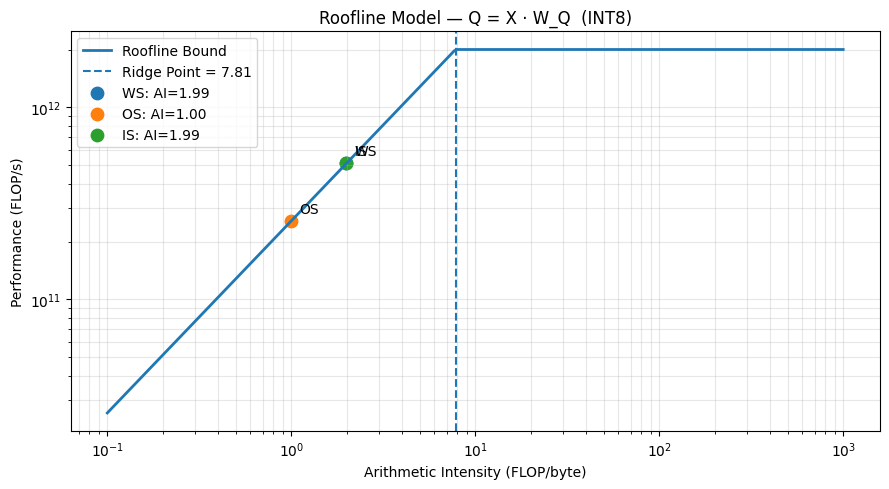

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# 1-a에서 구한 각 Dataflow의 총 DRAM 접근량 (Bytes) - 고정 상수
M, K, N = 512, 512, 512
dtype_bytes = 1
psum_bytes = 4

A_bytes = M * K * dtype_bytes
B_bytes = K * N * dtype_bytes
C_bytes = M * N * dtype_bytes
C_psum_bytes = M * N * psum_bytes

WS_total_dram = B_bytes + (M * K * N * dtype_bytes) + C_bytes
OS_total_dram = C_psum_bytes + (2 * M * K * N * dtype_bytes) + C_bytes
IS_total_dram = A_bytes + (M * K * N * dtype_bytes) + C_bytes

# 하드웨어 사양
peak_compute_ops = 2e12    # 2 TOPS
peak_bandwidth   = 256e9   # 256 GB/s

# ==============================================================================
# [문항 1] 총 연산량(FLOPs) 계산
# (조건: Fused Multiply-Add(FMA)를 고려하여 1개의 곱셈+덧셈 쌍을 2 FLOPs로 계산할 것)
# ==============================================================================
# TODO: 아래 빈칸을 올바른 수식으로 채우시오.

# GEMM C[M×N] = A[M×K] × B[K×N]는 M×N×K개의 MAC을 수행한다.
# 1 MAC = multiply 1회 + add 1회 = 2 FLOPs
FLOPs = 2 * M * K * N

print(f"Total FLOPs: {FLOPs:,}")


# ==============================================================================
# [문항 2] 각 Dataflow의 Arithmetic Intensity(AI) 및 하드웨어 Ridge Point 계산
# ==============================================================================
# TODO: 각 Dataflow의 AI와 하드웨어 고유의 Ridge Point를 구하는 수식을 작성하시오.

# AI = total operations / total DRAM bytes
AI_WS = FLOPs / WS_total_dram
AI_OS = FLOPs / OS_total_dram
AI_IS = FLOPs / IS_total_dram

# Ridge Point = Peak Compute / Peak Memory Bandwidth
ridge_point = peak_compute_ops / peak_bandwidth

print(f"Ridge Point: {ridge_point:.4f} FLOP/byte")
print(f"AI_WS: {AI_WS:.4f} FLOP/byte")
print(f"AI_OS: {AI_OS:.4f} FLOP/byte")
print(f"AI_IS: {AI_IS:.4f} FLOP/byte")


# ==============================================================================
# [문항 3] Roofline 기준 Bound 판별 (Compute-Bound vs Memory-Bound)
# ==============================================================================
# TODO: ridge_point와 각 Dataflow의 AI를 비교하여
#       "Compute-Bound" 또는 "Memory-Bound" 문자열이 저장되도록 조건문을 완성하시오.
ai_dict = {"WS": AI_WS, "OS": AI_OS, "IS": AI_IS}

for df in ["WS", "OS", "IS"]:
    current_ai = ai_dict[df]

    # ----------------------------------------------------
    # TODO: 대소 관계를 비교하는 조건문을 작성하시오.
    # AI가 ridge point 이상이면 peak compute에 도달 가능한 compute-bound,
    # AI가 ridge point보다 작으면 memory bandwidth가 성능을 제한하는 memory-bound.
    if current_ai >= ridge_point:
        region = "Compute-Bound"
    else:
        region = "Memory-Bound"
    # ----------------------------------------------------

    print(f"{df} Region: {region}")


# ==============================================================================
# [문항 4] Roofline 모델 시각화 (Matplotlib)
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_xscale('log')
ax.set_yscale('log')

# TODO 4-1: Roofline의 꺾임선을 표현하기 위한 x축 범위를 설정하시오 (logspace 활용)
# Roofline의 x축 범위: 주요 AI 값과 ridge point를 포함함
x_roofline = np.logspace(-1, 3, 300)

# TODO 4-2: Roofline 모델의 핵심 공식인 Attainable Performance 성능 한계선을 계산하시오.
#           (힌트: np.minimum 함수와 peak_compute_ops, peak_bandwidth 활용)
# Attainable Performance = min(Peak Compute, Bandwidth × Arithmetic Intensity)
y_roofline = np.minimum(peak_compute_ops, peak_bandwidth * x_roofline)

# Roofline 선 그리기
ax.plot(x_roofline, y_roofline, linewidth=2, label='Roofline Bound')

# TODO 4-3: Ridge Point 위치에 수직 점선(vlines 혹은 axvline)을 표시하시오.
ax.axvline(ridge_point, linestyle='--', linewidth=1.5, label=f'Ridge Point = {ridge_point:.2f}')

# TODO 4-4: WS, OS, IS 세 개의 동작점(Operating Point)을 그래프 위에 scatter로 표시하시오.
#           (힌트: x축은 각 Dataflow의 AI, y축은 해당 AI에서 가용한 Attainable Performance)
for df, ai in ai_dict.items():
    perf = min(peak_compute_ops, peak_bandwidth * ai)
    ax.scatter(ai, perf, s=80, label=f'{df}: AI={ai:.2f}')
    ax.annotate(df, (ai, perf), textcoords='offset points', xytext=(6, 6))

# 그래프 레이블링 및 스타일 설정
ax.set_xlabel('Arithmetic Intensity (FLOP/byte)')
ax.set_ylabel('Performance (FLOP/s)')
ax.set_title('Roofline Model — Q = X · W_Q  (INT8)')
ax.grid(True, alpha=0.3, which='both')
ax.legend()
plt.tight_layout()
plt.show()


### (1-c) 최적 Dataflow 선택 및 논술  [5 pts]

아래 4가지 조건을 **모두** 고려하여 최적 Dataflow를 선택하고, 선택 근거를 서술하시오.

1. **Global Buffer 크기 제약** (512 KB)  
2. **추론(Inference) 시 Weight Reuse**  
3. **INT8/INT32 Partial Sum 정밀도 문제**  
4. **Systolic Array 구현 친화성**

> 📝 아래 셀에 Markdown으로 작성하시오. (코드 불필요)


**답변 (여기에 작성):**

*(최적 Dataflow 선택: Weight Stationary (WS))*

*(선택 근거:)*

1. **Global Buffer 제약:**  
   W_Q의 크기는 512 × 512 × 1byte = 262,144 bytes = 256 KB이다. Global Buffer가 512 KB이므로 weight 전체는 한 번에 온칩에 올려둘 수 있다. 반면 Output Stationary에서 INT32 partial sum 전체를 유지하려면 512 × 512 × 4 bytes = 1 MB가 필요하므로 512 KB Global Buffer 제약을 초과한다.

2. **Inference 시 Weight Reuse:**  
   추론에서는 학습된 weight가 고정되어 있고 여러 token 또는 여러 입력에 반복적으로 사용된다. 따라서 weight를 한 번 로드한 뒤 PE나 on-chip buffer에 오래 유지하는 WS 방식은 DRAM 접근을 줄이는 데 유리하다.

3. **INT8/INT32 Partial Sum 정밀도 문제:**  
   입력과 weight는 INT8이지만, 곱셈 결과를 누산하는 partial sum은 overflow를 피하기 위해 보통 INT32로 유지한다. Output Stationary는 이 INT32 partial sum을 stationary data로 잡아야 하므로 저장 공간 요구량이 커진다. 이 문제에서는 전체 partial sum이 1 MB이므로 512 KB Global Buffer에 맞지 않는다. WS는 weight를 stationary로 두고 partial sum을 별도 누산 구조에서 처리하므로 OS보다 buffer 제약에 덜 민감하다.

4. **Systolic Array 구현 친화성:**  
   Weight Stationary는 각 PE에 weight를 고정하고 activation을 왼쪽에서 오른쪽으로 흘려보내는 구조와 잘 맞는다. 이 방식은 PE 간 데이터 이동이 규칙적이고, 동일 weight를 여러 activation과 곱할 수 있어 2D systolic array 구현에 적합하다.

*(결론:)*  
Transformer inference의 Q projection에서는 weight reuse가 크고, W_Q 전체 크기 256 KB가 512 KB Global Buffer 안에 들어가며, INT32 partial sum을 전체 stationary로 유지해야 하는 OS의 부담을 피할 수 있다. 따라서 이 문제의 조건에서는 Weight Stationary가 가장 적절한 dataflow이다.


---
## Problem 2 — Systolic Array Simulator  [30 pts]

### 개요

Weight Stationary 2D Systolic Array를 Python으로 구현한다.

**아키텍처 사양:**
- N × N Processing Element (PE) 배열
- 각 PE는 **하나의 stationary weight** 보유
- 입력(activation)은 **왼쪽 → 오른쪽** 으로 pass-through
- 출력 C = **A @ W.T** (C[i][j] = Σ_k A[i][k] · W[j][k])

**사이클 공식:** `Total ≈ K + 2·(N-1)`  
(setup latency N-1  +  computation K  +  drain N-1)


### (2-a) PE 클래스 구현  [5 pts]

`compute()` 메서드를 완성하시오.
- `psum += weight × act_in` (act_in이 None이 아닐 때)
- act_in을 오른쪽 PE로 **그대로 전달** (pass-through)
- Returns: act_out


In [22]:
# ─── (2-a) PE 클래스 ─────────────────────────────────────────────────────────
@dataclass
class PE:
    """Processing Element — Weight Stationary"""
    weight: int = 0          # Stationary weight  (load_weights 후 고정)
    psum:   int = 0          # Accumulated partial sum
    act_in: Optional[int] = None   # (참고용, 직접 사용 불필요)

    def compute(self, act_in: Optional[int]) -> Optional[int]:
        """
        역할:
          1. psum += weight × act_in  (act_in이 None이 아닐 때)
          2. act_in을 오른쪽 PE로 그대로 전달합니다 (pass-through)

        Args:
            act_in: 왼쪽에서 전달된 activation 값 (None = 버블)
        Returns:
            act_out: 오른쪽으로 전달될 값 (act_in과 동일)
        """
        if act_in is not None:
            self.psum += int(self.weight) * int(act_in)

        # TODO: 구현하시오
        # Weight Stationary 구조에서 activation은 소비된 뒤에도 오른쪽 PE로 전달됨
        act_out = act_in
        return act_out


### (2-b) load_weights 구현  [5 pts]

`SystolicArray.load_weights(W)` 를 완성하시오.

- W: shape `(N, N)` numpy 배열
- 각 PE에 weight를 올바르게 할당하여 `C = A @ W.T` 가 성립하도록 한다.
- **힌트:** C[i][j] = Σ_k A[i][k] · W[j][k]  →  PE[k][j].weight = ?

> 수식과 이유를 주석으로 반드시 포함할 것.


### (2-c) _skew_input 구현  [5 pts]

`SystolicArray._skew_input(A)` 를 완성하시오.

- A: shape `(M, K)` numpy 배열  
- Systolic skew: cycle `c` 에서 PE row `k` 는 `A[i][k]` 를 수신 (`i = c - k`)
- 유효 범위 외에는 `None` (bubble) 삽입
- **전체 사이클 수 = K + 2·(N-1)**
- Returns: `list[list[int | None]]`  — 길이 `K+2(N-1)`, 각 항목은 길이 N


### (2-d/e) run() 구현  [5 pts]

`SystolicArray.run(A)` 를 완성하시오.

- `_skew_input` 으로 스케줄을 생성
- 각 사이클마다 `PE.compute()` 를 호출
- `self.cycle` 을 총 실행 사이클 수만큼 증가
- 최종 출력 행렬 C (`dtype=np.int32`) 를 반환
- **아래 assert 를 반드시 통과해야 함:**

```python
assert np.allclose(C_hw, A @ W.T)
assert sa.total_cycles == N + 2*(N-1)
```


In [23]:
# ─── (2-b/c/d/e) SystolicArray 클래스 ──────────────────────────────────────────
class SystolicArray:
    """N×N Weight-Stationary 2D Systolic Array"""

    def __init__(self, N: int):
        self.N     = N
        self.pes   = [[PE() for _ in range(N)] for _ in range(N)]
        self.cycle = 0

    @property
    def total_cycles(self) -> int:
        return self.cycle

    # ── (2-b) ───────────────────────────────────────────────────────────────
    def load_weights(self, W: np.ndarray):
        """
        W: (N, N) weight matrix
        각 PE에 weight를 할당하여 run() 이후 C = A @ W.T 가 성립하도록 한다.
        수식과 이유를 주석으로 반드시 포함할 것.
        """
        assert W.shape == (self.N, self.N), "W must be square (N×N)"

        # TODO: 구현하시오
        # C = A @ W.T이므로 C[i, j] = Σ A[i, k] × W[j, k]
        # row k로 A[i, k]가 들어오고, column j가 output channel j에 대응하면
        # PE[k][j]는 A[i,k]와 곱해질 W[j,k]를 stationary weight로 가져야 함
        for k in range(self.N):
            for j in range(self.N):
                self.pes[k][j].weight = int(W[j, k])
                self.pes[k][j].psum = 0

    # ── (2-c) ───────────────────────────────────────────────────────────────
    def _skew_input(self, A: np.ndarray) -> list:
        """
        Systolic skew 적용 후 cycle-by-cycle activation 리스트 반환.
        총 사이클 수 = K + 2·(N-1)

        Returns:
            skewed: List[List[int|None]], shape [total_cycles][N]
        """
        M, K = A.shape
        N    = self.N
        # TODO: 구현하시오
        assert K == N, "This simplified simulator assumes K == N"

        total_cycles = K + 2 * (N - 1)
        skewed = []

        for c in range(total_cycles):
            row_inputs = []
            for k in range(N):
                # cycle c에서 PE row k가 받는 input은 A[i,k], i = c-k
                i = c - k
                if 0 <= i < M:
                    row_inputs.append(int(A[i, k]))
                else:
                    row_inputs.append(None)  # bubble
            skewed.append(row_inputs)

        return skewed

    # ── (2-d/e) ─────────────────────────────────────────────────────────────
    def run(self, A: np.ndarray) -> np.ndarray:
        """
        A: (M, K) input activation matrix  (M == N 을 가정)
        Returns:
            C: (M, N) int32 output  =  A @ W.T
        """
        M, K = A.shape
        N    = self.N
        # TODO: 구현하시오
        assert M == N and K == N, "This assignment test assumes A is N×N"

        # 여러 번 run해도 결과가 누적되지 않도록 상태 초기화
        self.cycle = 0
        for k in range(N):
            for j in range(N):
                self.pes[k][j].psum = 0

        skewed = self._skew_input(A)
        C = np.zeros((M, N), dtype=np.int32)

        for c, row_inputs in enumerate(skewed):
            # 1) PE 동작을 cycle마다 수행한다.
            #    각 row의 activation은 왼쪽에서 오른쪽으로 pass-through
            for k in range(N):
                act = row_inputs[k]
                for j in range(N):
                    act = self.pes[k][j].compute(act)

            # 2) 출력 행렬 누산.
            #    row_inputs[k] = A[i,k]이고 i = c-k 이므로,
            #    activation은 모든 output column j에 대해 W[j,k]와 곱해져 C[i,j]에 더함
            #    즉 C[i,j] += A[i,k] × W[j,k] 이고, 모든 k에 대해 누산하면 C = A @ W.T
            for k, act in enumerate(row_inputs):
                i = c - k
                if act is not None and 0 <= i < M:
                    for j in range(N):
                        C[i, j] += int(act) * int(self.pes[k][j].weight)

            self.cycle += 1

        return C


### (2-e) 검증 — assert 통과 확인

In [24]:
# ─── (2-e) 검증 (수정 금지) ──────────────────────────────────────────────────
N = 4
sa = SystolicArray(N)

np.random.seed(42)
A = np.random.randint(-8, 8, (N, N), dtype=np.int32)
W = np.random.randint(-8, 8, (N, N), dtype=np.int32)

sa.load_weights(W)
C_hw  = sa.run(A)
C_ref = A @ W.T

print("=== Correctness ===")
print(f"C_hw:\n{C_hw}")
print(f"C_ref (A @ W.T):\n{C_ref}")
assert np.allclose(C_hw, C_ref), "❌ MISMATCH: C_hw != A @ W.T"
print("  C_hw == A @ W.T  PASSED")

print()
print("=== Cycle Count ===")
print(f"  Actual   : {sa.total_cycles}")
print(f"  Expected : {N + 2*(N-1)}")
assert sa.total_cycles == N + 2*(N-1), \
    f"❌ Cycle mismatch: got {sa.total_cycles}, expected {N+2*(N-1)}"
print("  total_cycles == K + 2·(N-1)  PASSED")


=== Correctness ===
C_hw:
[[-25  -8 -85 -93]
 [ 11 -26  17  27]
 [ 27  46  31  29]
 [ 13  -3  47  56]]
C_ref (A @ W.T):
[[-25  -8 -85 -93]
 [ 11 -26  17  27]
 [ 27  46  31  29]
 [ 13  -3  47  56]]
  C_hw == A @ W.T  PASSED

=== Cycle Count ===
  Actual   : 10
  Expected : 10
  total_cycles == K + 2·(N-1)  PASSED


### (2-f) 분석: PE 활용률과 Skew Latency  [10 pts]

아래 질문에 답하시오.

**① PE 활용률 공식 유도 (수식 포함):**  
- 전체 사이클 수, 유효 연산 수, PE 활용률(%) 공식을 각각 유도하시오.

**② N에 따른 PE 활용률 변화:**  
- N = 4, 8, 16, 32 각각에 대해 PE 활용률과 Skew Latency를 계산하고 표로 정리하시오.
- 그래프로 시각화하시오 (x=N, y=PE utilization %).

**③ Skew Latency 정의 및 영향:**  
- Skew Latency가 무엇인지 설명하고, N이 커질수록 PE 활용률이 어떻게 변하는지 서술하시오.


=== (2-f) PE Utilization vs N ===
   N |  Total Cycles |  PE Util (%) |  Skew Latency
------------------------------------------------------
   4 |            10 |       40.00% |             6
   8 |            22 |       36.36% |            14
  16 |            46 |       34.78% |            30
  32 |            94 |       34.04% |            62


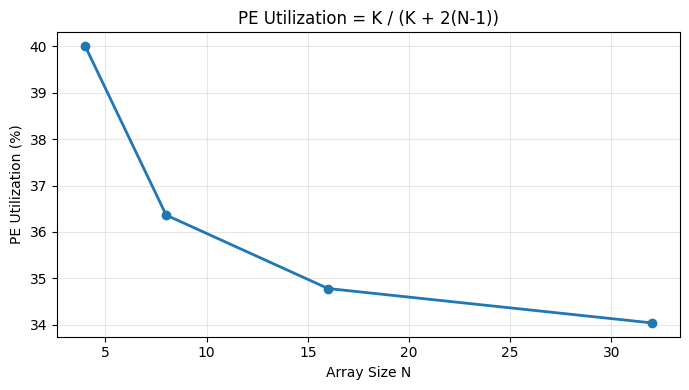

In [25]:
# ─── (2-f) PE 활용률 분석 ─────────────────────────────────────────────────────
# TODO: 아래를 완성하시오

print("=== (2-f) PE Utilization vs N ===")
print(f"{'N':>4} | {'Total Cycles':>13} | {'PE Util (%)':>12} | {'Skew Latency':>13}")
print("-" * 54)

N_list = [4, 8, 16, 32]
util_list = []

for N in N_list:
    K = N
    total_cycles = K + 2 * (N - 1)

    # 유효 MAC 수 = N×N×K = N^3
    # 전체 PE slot 수 = N×N×total_cycles
    # PE Utilization = 유효 MAC 수 / 전체 PE slot 수 × 100
    #                = (N^2×K) / (N^2×total_cycles) × 100
    #                = K / total_cycles × 100
    pe_util = K / total_cycles * 100

    # setup latency = drain latency = N-1 cycle
    skew_lat = 2 * (N - 1)

    util_list.append(pe_util)
    print(f"{N:>4} | {total_cycles:>13} | {pe_util:>11.2f}% | {skew_lat:>13}")

# TODO: PE 활용률 그래프 (x=N, y=PE util %)
fig, ax = plt.subplots(figsize=(7, 4))
# TODO: 그래프 코드
ax.plot(N_list, util_list, marker='o', linewidth=2)
ax.set_xlabel('Array Size N')
ax.set_ylabel('PE Utilization (%)')
ax.set_title('PE Utilization = K / (K + 2(N-1))')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# TODO: ③ 서술형 답변은 아래 Markdown 셀에 작성


**① PE 활용률 공식 유도:**

N×N systolic array에서 총 PE 개수는 N^2개이다. 행렬곱에서 유효 MAC 연산 수는 M × N × K이고, 과제에서는 M=N=K이므로 유효 MAC 연산 수는 N^3이다.

전체 실행 cycle은 setup latency N-1, 실제 계산 구간 K, drain latency N-1를 합친 값이다.

∴ Total Cycles = K + 2(N-1)

전체 PE slot 수는 전체 실행 cycle에 N^2을 곱하면 된다.

∴ Total PE slots = N^2 × Total Cycles

따라서 PE 활용률은 다음과 같다.

∴ PE Utilization = (N^2K)/(N^2 × (K + 2(N-1))) × 100
= K/(K + 2(N-1)) × 100

이떄 K=N이므로, 최종적으로 아래와 같이 쓸 수 있다.

∴ PE Utilization = N/(N + 2(N-1)) × 100

**② 분석 표:**

| N | Total Cycles | PE Utilization | Skew Latency, setup+drain |
|---:|---:|---:|---:|
| 4 | 10 | 40.00% | 6 |
| 8 | 22 | 36.36% | 14 |
| 16 | 46 | 34.78% | 30 |
| 32 | 94 | 34.04% | 62 |

**③ Skew Latency 설명:**

Skew latency는 systolic array에 데이터를 대각선 형태로 밀어 넣기 위해 생기는 추가 지연이다. 처음에는 모든 PE가 동시에 유효한 데이터를 받지 못하므로 setup 구간이 필요하고, 마지막 입력이 들어간 뒤에도 남은 데이터와 partial sum이 array를 빠져나가는 drain 구간이 필요하다. 이 과제에서는 setup latency가 N-1, drain latency가 N-1이므로 전체 skew overhead는 2(N-1) cycle이다.

N이 커지면 절대적인 skew latency는 증가한다. 이 문제처럼 K=N으로 함께 커지는 경우 PE 활용률은 N/(N+2(N-1))로 계산되며, N이 커질수록 약 1/3, 즉 33.3% 근처로 수렴한다. 따라서 array가 커질수록 총 처리량 자체는 증가할 수 있지만, 동일한 단일 N×N GEMM만 놓고 보면 setup/drain overhead 떄문에 PE 활용률은 100%에 도달하지 못한다.